<a href="https://colab.research.google.com/github/uChicoProgramming/Analise_Estat-stica_Teste_AB/blob/main/InsurancyPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [14]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [20]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
X['sex'] = X['sex'].map({'male': 1, 'female': 0})
X['region'] = X['region'].map({'southwest': 1, 'southeast': 2, 'northwest': 3, 'northeast': 4})
X['smoker'] = X['smoker'].map({'yes': 1, 'no': 0})
y = df['charges']

/tmp/ipykernel_1106/978723821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['sex'] = X['sex'].map({'male': 1, 'female': 0})
/tmp/ipykernel_1106/978723821.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['region'] = X['region'].map({'southwest': 1, 'southeast': 2, 'northwest': 3, 'northeast': 4})
/tmp/ipykernel_1106/978723821.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

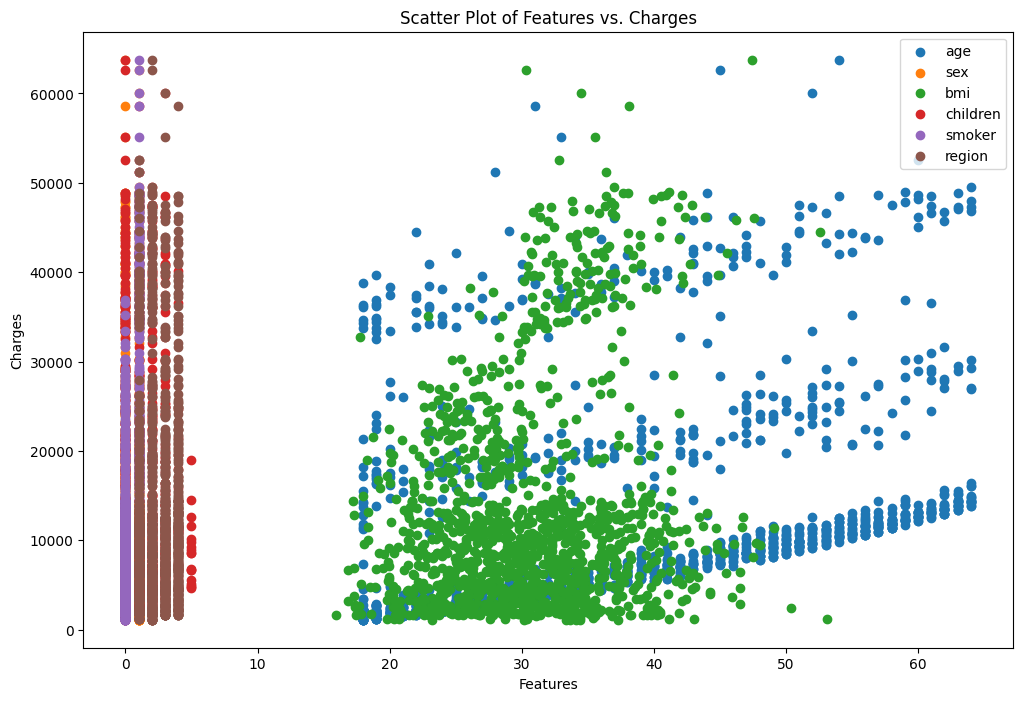

In [38]:
cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
def scatter_plot(X, y, cols):
  plt.figure(figsize=(12, 8))
  for col in cols:
    plt.scatter(X[col], y, label=col)
  plt.xlabel('Features')
  plt.ylabel('Charges')
  plt.title('Scatter Plot of Features vs. Charges')
  plt.legend()

scatter_plot(X, y, cols)

In [31]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [35]:
y_pred = model.predict(X)

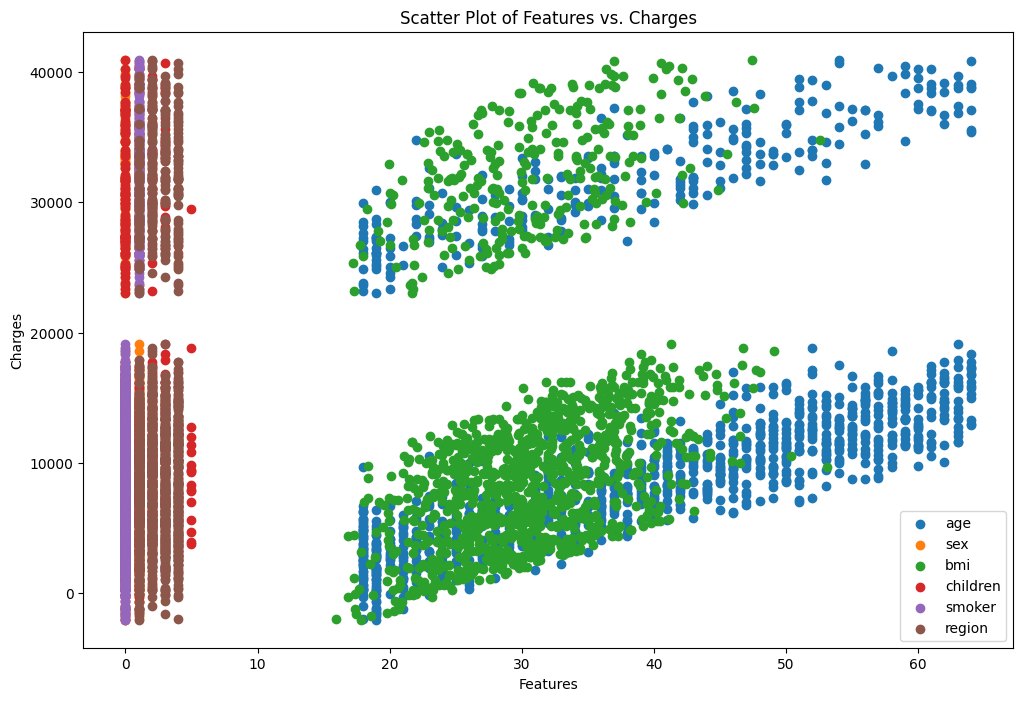

In [39]:
scatter_plot(X, y_pred, cols)

In [46]:
# R² Score (Quanto mais próximo de 1.0, melhor)
print(f"R² Score: {r2_score(y, y_pred):.2f}")

# MSE (Quanto menor, melhor)
print(f"MSE: {mean_squared_error(y, y_pred):.2f}")

R² Score: 0.75
MSE: 36527659.89


In [ ]:
!git init